In [11]:
import sklearn as sk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [12]:
df=pd.read_csv("/content/drive/MyDrive/DATASETS/winequality-red.csv")

In [13]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [15]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [16]:
df.shape

(1599, 12)

In [19]:
df.isnull().sum()

240


In [23]:

X = df.drop('quality', axis=1)

y = df['quality']


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)



In [26]:

from sklearn.ensemble import RandomForestClassifier


model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')


model.fit(X_train_scaled, y_train)



RandomForestClassifier(class_weight='balanced', random_state=42)

In [27]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = model.predict(X_test_scaled)

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.6906

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.74      0.77      0.76       136
           6       0.63      0.75      0.69       128
           7       0.79      0.47      0.59        40
           8       1.00      0.33      0.50         3

    accuracy                           0.69       320
   macro avg       0.53      0.39      0.42       320
weighted avg       0.68      0.69      0.67       320


Confusion Matrix:
[[  0   0   1   1   0   0]
 [  0   0   7   4   0   0]
 [  0   1 105  30   0   0]
 [  0   0  27  96   5   0]
 [  0   0   2  19  19   0]
 [  0   0   0   2   0   1]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

class_labels = sorted(y_test.unique())


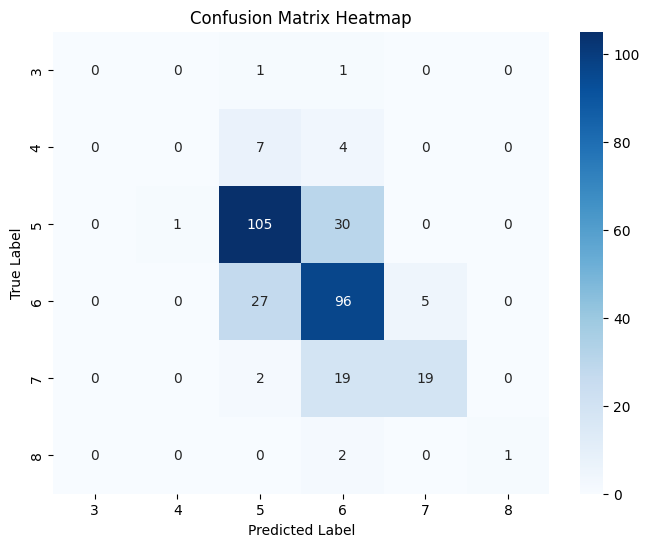

In [30]:

plt.figure(figsize=(8, 6))


sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')


plt.show()

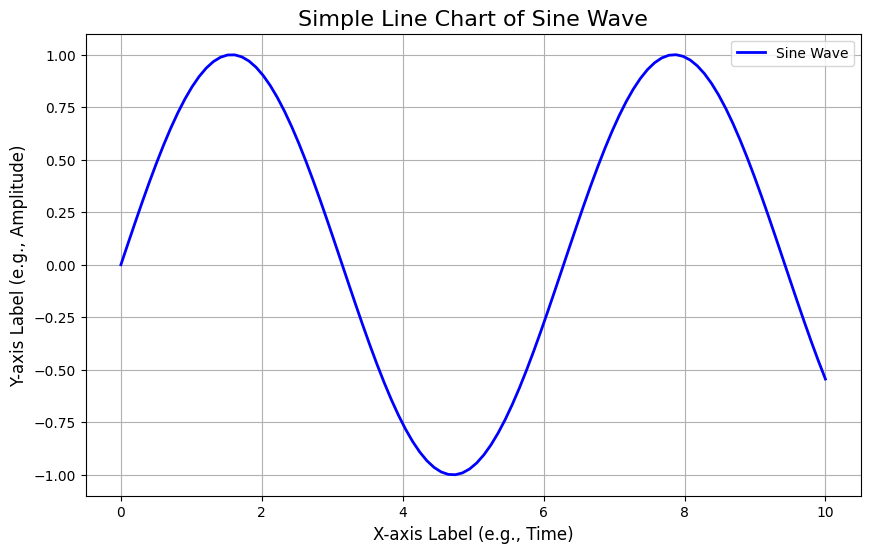

In [32]:

import matplotlib.pyplot as plt
import numpy as np


x_values = np.linspace(0, 10, 100)


y_values = np.sin(x_values)


plt.figure(figsize=(10, 6))


plt.plot(x_values, y_values, label='Sine Wave', color='blue', linestyle='-', linewidth=2)


plt.title('Simple Line Chart of Sine Wave', fontsize=16)


plt.xlabel('X-axis Label (e.g., Time)', fontsize=12)


plt.ylabel('Y-axis Label (e.g., Amplitude)', fontsize=12)


plt.grid(True)


plt.legend(fontsize=10)


plt.show()
